In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
warnings.filterwarnings('ignore')

In [2]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

In [3]:
# ── PATHS ────────────────────────────────────────────────────
COMBINED_CSV = "/Users/aditibharadwaj/Documents/experiqs/MH_SOC/S2_timeseries_combined.csv"

# ── FEATURE CONFIG ───────────────────────────────────────────
BAND_COLS  = ["B2", "B3", "B4", "B8", "B11", "B12"]
VALID_SCL  = [4, 5]

# ── SPATIAL CV CONFIG ────────────────────────────────────────
N_SPATIAL_FOLDS = 5
SPATIAL_RANDOM_STATE = 42

# ── TRAINING CONFIG ──────────────────────────────────────────
N_ESTIMATORS = 500
EARLY_STOPPING_ROUNDS = 30   
VAL_FRACTION = 0.15          

print(f"Optional libs available -- xgboost: {HAS_XGB}, lightgbm: {HAS_LGBM}, catboost: {HAS_CATBOOST}")

Optional libs available -- xgboost: True, lightgbm: False, catboost: False


In [4]:
df = pd.read_csv(COMBINED_CSV, low_memory=False)
df["tile_date"] = pd.to_datetime(df["tile_date"])
df["sample_date_clean"] = pd.to_datetime(df["sample_date_clean"])

df = df[df["SCL"].isin(VALID_SCL)].copy()
df = df.dropna(subset=BAND_COLS).copy()
df = df.sort_values(["id", "tile_date"]).reset_index(drop=True)

obs_counts = df.groupby("id").size()
valid_ids = obs_counts[obs_counts >= 5].index
df = df[df["id"].isin(valid_ids)].copy()

print(f"Total rows:        {len(df):,}")
print(f"Unique points:     {df['id'].nunique():,}")
print(f"Avg obs per point: {len(df)/df['id'].nunique():.1f}")
print(f"OC range:          {df['OC'].min():.3f} — {df['OC'].max():.3f}")

point_meta = (
    df.groupby("id")[["lat_key", "lon_key", "OC"]]
    .first()
    .reset_index()
)

Total rows:        3,778,662
Unique points:     29,942
Avg obs per point: 126.2
OC range:          0.007 — 3.500


In [5]:
coords = point_meta[["lat_key", "lon_key"]].values
kmeans = KMeans(n_clusters=N_SPATIAL_FOLDS, random_state=SPATIAL_RANDOM_STATE, n_init=10)
point_meta["spatial_block"] = kmeans.fit_predict(coords)

block_counts = point_meta["spatial_block"].value_counts().sort_index()
print("Points per spatial block:")
for block, count in block_counts.items():
    print(f"  Block {block}: {count:,} points")

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    point_meta["lon_key"], point_meta["lat_key"],
    c=point_meta["spatial_block"], cmap="tab10", s=5, alpha=0.6
)
plt.colorbar(scatter, ax=ax, label="Spatial Block")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Spatial Blocks (K={N_SPATIAL_FOLDS}) — Maharashtra")
plt.tight_layout()
plt.savefig("spatial_blocks_trees.png", dpi=150)
plt.close()


Points per spatial block:
  Block 0: 5,551 points
  Block 1: 6,681 points
  Block 2: 7,266 points
  Block 3: 5,640 points
  Block 4: 4,804 points


In [6]:
def build_tabular_features(df_subset, band_cols, scaler=None, fit_scaler=False):
    """
    Collapse each point's full chronological observation history into
    one row of summary statistics per band (+ NDVI/BSI).

    Trees can't read a sequence, so this hands them explicit
    mean / spread / trend / most-recent-value signals instead of
    raw per-timestep bands -- the tabular equivalent of what an LSTM
    would otherwise learn implicitly from the sequence.

    Returns X (DataFrame), y (array), ids (list), fitted_scaler
    """
    df_subset = df_subset.copy()
    df_subset["NDVI"] = (df_subset["B8"] - df_subset["B4"]) / (df_subset["B8"] + df_subset["B4"] + 1e-6)
    df_subset["BSI"] = (
        (df_subset["B11"] + df_subset["B4"]) - (df_subset["B8"] + df_subset["B2"])
    ) / (
        (df_subset["B11"] + df_subset["B4"]) + (df_subset["B8"] + df_subset["B2"]) + 1e-6
    )
    value_cols = band_cols + ["NDVI", "BSI"]

    rows, ids, targets = [], [], []
    for pt_id, group in df_subset.groupby("id", sort=False):
        group = group.sort_values("tile_date")
        feat = {}
        for col in value_cols:
            vals = group[col].to_numpy(dtype=float)
            feat[f"{col}_mean"] = np.mean(vals)
            feat[f"{col}_std"] = np.std(vals)
            feat[f"{col}_min"] = np.min(vals)
            feat[f"{col}_max"] = np.max(vals)
            feat[f"{col}_range"] = vals.max() - vals.min()
            feat[f"{col}_first"] = vals[0]
            feat[f"{col}_last"] = vals[-1]
            if len(vals) >= 2:
                feat[f"{col}_slope"] = np.polyfit(np.arange(len(vals)), vals, 1)[0]
            else:
                feat[f"{col}_slope"] = 0.0
        feat["n_obs"] = len(group)
        rows.append(feat)
        ids.append(pt_id)
        targets.append(float(group["OC"].iloc[0]))

    X = pd.DataFrame(rows, index=ids)
    y = np.array(targets, dtype=np.float32)

    if fit_scaler:
        scaler = StandardScaler()
        X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    elif scaler is not None:
        X = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)

    return X, y, ids, scaler


def get_models():
    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=N_ESTIMATORS, min_samples_leaf=2, n_jobs=-1,
            random_state=SPATIAL_RANDOM_STATE,
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=N_ESTIMATORS, min_samples_leaf=2, n_jobs=-1,
            random_state=SPATIAL_RANDOM_STATE,
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_depth=6, learning_rate=0.05, max_iter=N_ESTIMATORS,
            random_state=SPATIAL_RANDOM_STATE,
        ),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=N_ESTIMATORS, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
            random_state=SPATIAL_RANDOM_STATE,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        )
    if HAS_LGBM:
        models["LightGBM"] = LGBMRegressor(
            n_estimators=N_ESTIMATORS, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
            random_state=SPATIAL_RANDOM_STATE, verbosity=-1,
        )
    if HAS_CATBOOST:
        models["CatBoost"] = CatBoostRegressor(
            iterations=N_ESTIMATORS, depth=6, learning_rate=0.05,
            random_seed=SPATIAL_RANDOM_STATE, verbose=False,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        )
    return models


def compute_metrics(y_true, y_pred):
    return {
        "test_r2": float(r2_score(y_true, y_pred)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "test_mae": float(mean_absolute_error(y_true, y_pred)),
    }


def train_one_fold_trees(df_train, df_val, df_test, fold, parent_run_id):
    """Train every tree model on one spatial fold, each as its own nested
    MLflow run (mirrors train_one_fold from the LSTM script, one level
    deeper since we're comparing several model types per fold)."""

    X_tr, y_tr, _, scaler = build_tabular_features(df_train, BAND_COLS, fit_scaler=True)
    X_val, y_val, _, _ = build_tabular_features(df_val, BAND_COLS, scaler=scaler)
    X_te, y_te, _, _ = build_tabular_features(df_test, BAND_COLS, scaler=scaler)

    X_tr_full = pd.concat([X_tr, X_val])
    y_tr_full = np.concatenate([y_tr, y_val])

    fold_results = {}
    for name, model in get_models().items():
        with mlflow.start_run(
            run_name=f"{name}_fold{fold}", nested=True,
            tags={"fold": str(fold), "model": name, "parent_run_id": parent_run_id},
        ):
            mlflow.log_params({
                "fold": fold, "model": name,
                "n_train": len(X_tr), "n_val": len(X_val), "n_test": len(X_te),
                "n_features": X_tr.shape[1],
            })

            if name == "XGBoost":
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            elif name == "LightGBM":
                model.fit(
                    X_tr, y_tr, eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
                )
            elif name == "CatBoost":
                model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
            else:
                model.fit(X_tr_full, y_tr_full)

            preds = model.predict(X_te)
            metrics = compute_metrics(y_te, preds)
            mlflow.log_metrics(metrics)
            mlflow.sklearn.log_model(model, f"{name}_fold{fold}")

            print(f"  [{name}] Fold {fold} | R²: {metrics['test_r2']:.4f} | "
                  f"RMSE: {metrics['test_rmse']:.4f} | MAE: {metrics['test_mae']:.4f}")

            fold_results[name] = {
                "fold": fold, **metrics, "preds": preds, "targets": y_te,
            }
    return fold_results


In [7]:
mlflow.set_experiment("SOC_RF_Tabular") 
all_results = {}  

with mlflow.start_run(run_name="TreeModels_SpatialCV") as parent_run:

    mlflow.log_params({
        "model_family": "trees",
        "n_spatial_folds": N_SPATIAL_FOLDS,
        "band_cols": str(BAND_COLS),
        "valid_scl": str(VALID_SCL),
        "n_estimators": N_ESTIMATORS,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "total_points": df["id"].nunique(),
        "has_xgboost": HAS_XGB, "has_lightgbm": HAS_LGBM, "has_catboost": HAS_CATBOOST,
    })
    mlflow.log_artifact("spatial_blocks_trees.png")

    for fold in range(N_SPATIAL_FOLDS):
        print(f"\n── Fold {fold+1}/{N_SPATIAL_FOLDS} ────────────────────────")

        test_ids = point_meta[point_meta["spatial_block"] == fold]["id"].values
        train_ids = point_meta[point_meta["spatial_block"] != fold]["id"].values

        n_val = max(1, int(len(train_ids) * VAL_FRACTION))
        rng = np.random.default_rng(42 + fold)
        rng.shuffle(train_ids)
        val_ids = train_ids[:n_val]
        train_ids = train_ids[n_val:]

        print(f"  Train: {len(train_ids):,} | Val: {len(val_ids):,} | Test: {len(test_ids):,}")

        df_train = df[df["id"].isin(train_ids)]
        df_val = df[df["id"].isin(val_ids)]
        df_test = df[df["id"].isin(test_ids)]

        fold_results = train_one_fold_trees(
            df_train, df_val, df_test, fold=fold, parent_run_id=parent_run.info.run_id
        )
        for name, result in fold_results.items():
            all_results.setdefault(name, []).append(result)

    # ── Aggregate CV metrics per model ───────────────────────
    summary_rows = []
    for name, results in all_results.items():
        r2s = [r["test_r2"] for r in results]
        rmses = [r["test_rmse"] for r in results]
        maes = [r["test_mae"] for r in results]
        mlflow.log_metrics({
            f"{name}_cv_r2_mean": np.mean(r2s), f"{name}_cv_r2_std": np.std(r2s),
            f"{name}_cv_rmse_mean": np.mean(rmses), f"{name}_cv_rmse_std": np.std(rmses),
            f"{name}_cv_mae_mean": np.mean(maes), f"{name}_cv_mae_std": np.std(maes),
        })
        summary_rows.append({
            "model": name,
            "r2_mean": np.mean(r2s), "r2_std": np.std(r2s),
            "rmse_mean": np.mean(rmses), "rmse_std": np.std(rmses),
            "mae_mean": np.mean(maes), "mae_std": np.std(maes),
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("rmse_mean")
    print("\n── Spatial CV Summary (sorted by RMSE) ────────────")
    print(summary_df.to_string(index=False))
    summary_df.to_csv("tree_cv_summary.csv", index=False)
    mlflow.log_artifact("tree_cv_summary.csv")

missing = [n for n, ok in [("xgboost", HAS_XGB), ("lightgbm", HAS_LGBM), ("catboost", HAS_CATBOOST)] if not ok]
if missing:
    print(f"\n[!] Skipped (not installed): {', '.join(missing)} -- pip install {' '.join(missing)}")



── Fold 1/5 ────────────────────────
  Train: 20,733 | Val: 3,658 | Test: 5,551


2026/06/27 09:50:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 09:50:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [RandomForest] Fold 0 | R²: -0.1969 | RMSE: 0.2764 | MAE: 0.1959


2026/06/27 09:51:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 09:51:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [ExtraTrees] Fold 0 | R²: -0.1347 | RMSE: 0.2691 | MAE: 0.1904


...

  [ExtraTrees] Fold 4 | R²: -0.1738 | RMSE: 0.2512 | MAE: 0.1888


2026/06/27 09:57:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 09:57:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [HistGradientBoosting] Fold 4 | R²: -0.1866 | RMSE: 0.2525 | MAE: 0.1838


2026/06/27 09:57:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 09:57:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [XGBoost] Fold 4 | R²: -0.2222 | RMSE: 0.2563 | MAE: 0.1875

── Spatial CV Summary (sorted by RMSE) ────────────
               model   r2_mean   r2_std  rmse_mean  rmse_std  mae_mean  mae_std
          ExtraTrees -0.444592 0.853148   0.403722  0.126832  0.283873 0.093717
        RandomForest -0.621592 1.142936   0.418256  0.134459  0.294828 0.102640
HistGradientBoosting -0.625837 1.181014   0.419456  0.140478  0.290054 0.105362
             XGBoost -0.721414 1.361469   0.425168  0.145182  0.298630 0.114415

[!] Skipped (not installed): lightgbm, catboost -- pip install lightgbm catboost


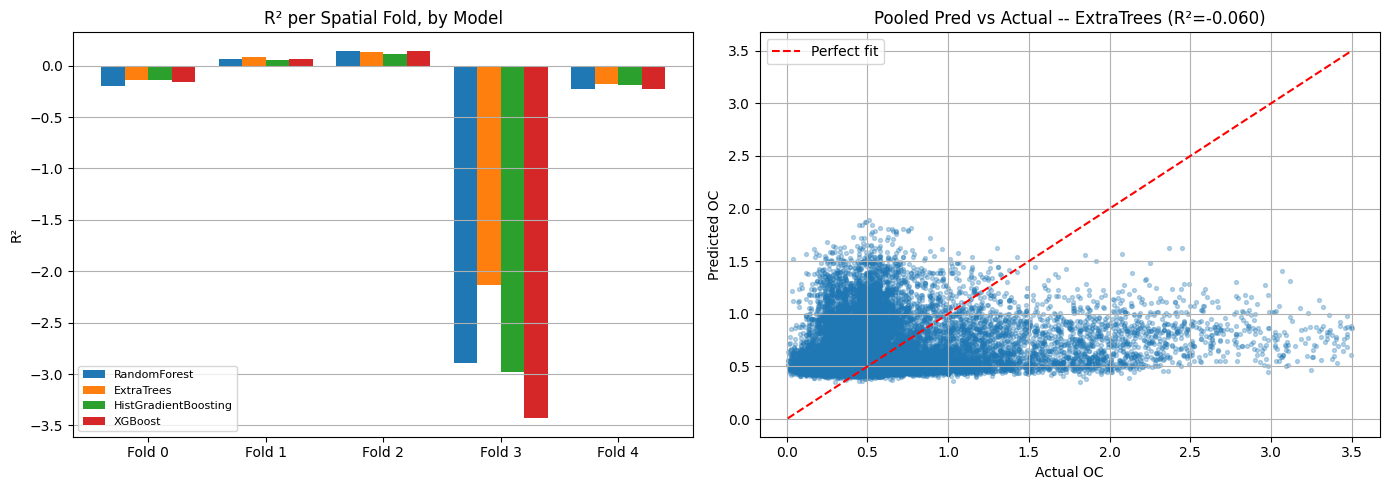

Saved: tree_cv_diagnostics.png


In [8]:
best_model = summary_df.iloc[0]["model"]
best_results = all_results[best_model]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(all_results.keys())
n_models = len(model_names)
width = 0.8 / n_models
x = np.arange(N_SPATIAL_FOLDS)
for i, name in enumerate(model_names):
    r2s_by_fold = [r["test_r2"] for r in sorted(all_results[name], key=lambda r: r["fold"])]
    axes[0].bar(x + i * width, r2s_by_fold, width=width, label=name)
axes[0].set_xticks(x + width * (n_models - 1) / 2)
axes[0].set_xticklabels([f"Fold {f}" for f in range(N_SPATIAL_FOLDS)])
axes[0].set_ylabel("R²")
axes[0].set_title("R² per Spatial Fold, by Model")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y")

all_preds = np.concatenate([r["preds"] for r in best_results])
all_targets = np.concatenate([r["targets"] for r in best_results])
overall_r2 = r2_score(all_targets, all_preds)

axes[1].scatter(all_targets, all_preds, alpha=0.3, s=8)
mn, mx = all_targets.min(), all_targets.max()
axes[1].plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
axes[1].set_xlabel("Actual OC"); axes[1].set_ylabel("Predicted OC")
axes[1].set_title(f"Pooled Pred vs Actual -- {best_model} (R²={overall_r2:.3f})")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("tree_cv_diagnostics.png", dpi=150)
plt.show()
print("Saved: tree_cv_diagnostics.png")
